In [ ]:
#%pip install pandas matplotlib seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
df = pd.read_csv('../data/processed/BankChurners_clean.csv')
df.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Avg_Trans_Amt,Activity_Segment,Revolving_Use
0,0,45,0,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,27.238095,Low,1
1,0,49,1,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,39.121212,Low,1
2,0,51,0,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,94.350000,Low,0
3,0,40,1,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,58.550000,Low,1
4,0,40,0,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000,29.142857,Low,0


### Para construir un perfil de cliente que cancela su tarjeta de crédito vamos a seguir una estructura ordenada

### 1. En primer lugar calcularemos la tasa de churn para tenerla como punto de referencia

In [3]:
df['Attrition_Flag'].value_counts(normalize=True) * 100

Attrition_Flag
0    83.934038
1    16.065962
Name: proportion, dtype: float64

### Este es el número de referencia que usaremos durante todo el EDA: cualquier subgrupo que se aleje claramente de este 16% (por arriba o por abajo) será una pista relevante para el perfil que buscamos. También conviene tenerlo en cuenta para otra cosa: con un desbalance de clases de más o menos 84/16, cualquier media o proporción que calculemos sin segmentar estará dominada por el grupo mayoritario, por eso todo el resto del EDA se basa en comparar grupos (groupby por Attrition_Flag), nunca en mirar el dataset completo de forma agregada

### 2. Continuamos con el perfil demográfico

### 2.1 Edad

In [4]:
df.groupby('Attrition_Flag')['Customer_Age'].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition_Flag,,,,,,,,
0,8500.0,46.262118,8.081157,26.0,41.0,46.0,52.0,73.0
1,1627.0,46.659496,7.665652,26.0,41.0,47.0,52.0,68.0


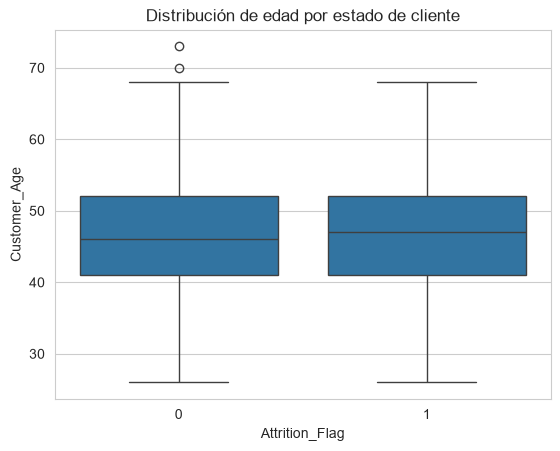

In [5]:
sns.boxplot(data=df, x='Attrition_Flag', y='Customer_Age')
plt.title('Distribución de edad por estado de cliente')
plt.show()

### Mdias prácticamente idénticas (46.26 vs 46.66 años), misma mediana casi (46 vs 47), mismos cuartiles. El boxplot lo confirma visualmente: la edad no diferencia al cliente que cancela

### 2.2 Género

In [6]:
pd.crosstab(df['Gender'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Gender,,
0,85.384777,14.615223
1,82.642777,17.357223


### 14.6% de churn en hombres vs 17.4% en mujeres. Hay una diferencia de más o menos 2.7 puntos, ligeramente por encima de la base (16.07%) en mujeres y por debajo en hombres, pero es un efecto modesto: no constituye un perfil claro por sí solo

### 2.3 Dependientes, educación, estado civil e ingresos

In [9]:
pd.crosstab(df['Dependent_count'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Dependent_count,,
0,85.066372,14.933628
1,85.364527,14.635473
2,84.293785,15.706215
3,82.357247,17.642753
4,83.481576,16.518424
5,84.905660,15.094340


### Todas las categorías oscilan entre 14.6% y 17.6%, sin un patrón creciente o decreciente claro con el número de hijos/dependientes. Sin relación aparente

In [10]:
pd.crosstab(df['Education_Level'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Education_Level,,
College,84.797631,15.202369
Doctorate,78.935698,21.064302
Graduate,84.430946,15.569054
High School,84.798808,15.201192
Post-Graduate,82.170543,17.829457
Uneducated,84.061870,15.938130
Unknown,83.146807,16.853193


### La mayoría de categorías rondan 15-16%, muy cerca de la base. Hay dos que destacan algo: Doctorate (21.06%) y Post-Graduate (17.83%) están por encima. Conviene comprobar el tamaño de Doctorate, porque si es un grupo pequeño, ese porcentaje puede ser ruido estadístico, no una señal real. Comprobamos su tamaño:

In [13]:
df['Education_Level'].value_counts()

Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64

### Confirmado. Doctorate representa solo 451 clientes (4.5% del dataset), el grupo más pequeño de las 7 categorías, junto con Post-Graduate (516, también el segundo más pequeño). Con tamaños de muestra tan reducidos, una diferencia de 21% vs 16% de base puede deberse perfectamente a variabilidad aleatoria, no a un patrón real (con más o menos 451 casos y 16% de tasa esperada, el margen de error de la proporción es considerable)

In [11]:
pd.crosstab(df['Marital_Status'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Marital_Status,,
Divorced,83.823529,16.176471
Married,84.873053,15.126947
Single,83.058585,16.941415
Unknown,82.777036,17.222964


### Rango estrecho (15.1% - 17.2%), sin patrón destacable. Single y Unknown ligeramente por encima de la base, Married ligeramente por debajo, pero diferencias pequeñas

In [12]:
pd.crosstab(df['Income_Category'], df['Attrition_Flag'], normalize='index') * 100

Attrition_Flag,0,1
Income_Category,,
$120K +,82.668501,17.331499
$40K - $60K,84.860335,15.139665
$60K - $80K,86.519258,13.480742
$80K - $120K,84.234528,15.765472
Less than $40K,82.813816,17.186184
Unknown,83.183453,16.816547


### Rango similarmente estrecho (13.5% - 17.3%). Curiosamente, $120K + (17.3%) y Less than $40K (17.2%), los dos extremos de la escala de ingresos, tienen churn algo más alto que las categorías intermedias. Podría sugerir un patrón en forma de "U" (tanto rentas bajas como muy altas cancelan algo más), pero las diferencias son pequeñas (3-4 puntos) para considerarlo concluyente sin más evidencia

### Ninguna variable demográfica aporta una señal sólida y fiable sobre el churn. Las pequeñas desviaciones que vemos (Doctorate, género, ingresos extremos) son sutiles y, en al menos un caso, explicables por tamaño de muestra pequeño. No constituyen un perfil demográfico identificable